In [4]:
OPENDS_NAME = "MO"
TASK = "join"
QUERY_TABLES_PATH = 'join_tables.csv'
#DATASET_PATH = f"datasets_{OPENDS_NAME}"
DATASET_PATH = f"datasets_{OPENDS_NAME}/comune di modena/"
MAX_UNIQUE_VALUES = 10
N_REPRESENTATIVE_ROWS = 3

In [5]:
OPENDS_NAME = "UK"
TASK = "join"
LAKEBENCH_GT_PATH = f'../data/lakebench/ground truth/opendata_{TASK}_ground_truth.csv' 
OUTPUT_CLEANED_GT = f'../data/{TASK}/{OPENDS_NAME}_ground_truth.csv'
DATASET_PATH = f'../data/datasets/datasets_{OPENDS_NAME}.zip'

In [6]:
import os
os.environ['OLLAMA_HOST'] = 'http://localhost:11434'
os.environ['no_proxy'] = 'localhost,127.0.0.1'

In [7]:
import pandas as pd
ground_truth = pd.read_csv(OUTPUT_CLEANED_GT)
# select only query_table and candidate_table that starts for UK
#uk_tables = ground_truth[(ground_truth['query_table'].str.startswith(OPENDS_NAME)) & (ground_truth['candidate_table'].str.startswith(OPENDS_NAME))]
#uk_tables = uk_tables.reset_index(drop=True)
op_tables = ground_truth
op_tables

,query_table,candidate_table
0,UK_CSV0000000000001955.csv,UK_CSV0000000000000270.csv
1,UK_CSV0000000000001626.csv,UK_CSV0000000000003912.csv
2,UK_CSV0000000000000759.csv,UK_CSV0000000000011254.csv
3,UK_CSV0000000000002588.csv,UK_CSV0000000000007746.csv
4,UK_CSV0000000000000987.csv,UK_CSV0000000000009096.csv
...,...,...
177,UK_CSV0000000000004295.csv,UK_CSV0000000000010811.csv
178,UK_CSV0000000000004295.csv,UK_CSV0000000000002491.csv
179,UK_CSV0000000000004295.csv,UK_CSV0000000000008979.csv
180,UK_CSV0000000000004295.csv,UK_CSV0000000000005090.csv


In [8]:
op_tables

,query_table,candidate_table
0,UK_CSV0000000000001955.csv,UK_CSV0000000000000270.csv
1,UK_CSV0000000000001626.csv,UK_CSV0000000000003912.csv
2,UK_CSV0000000000000759.csv,UK_CSV0000000000011254.csv
3,UK_CSV0000000000002588.csv,UK_CSV0000000000007746.csv
4,UK_CSV0000000000000987.csv,UK_CSV0000000000009096.csv
...,...,...
177,UK_CSV0000000000004295.csv,UK_CSV0000000000010811.csv
178,UK_CSV0000000000004295.csv,UK_CSV0000000000002491.csv
179,UK_CSV0000000000004295.csv,UK_CSV0000000000008979.csv
180,UK_CSV0000000000004295.csv,UK_CSV0000000000005090.csv


In [9]:
from dotenv import load_dotenv
load_dotenv()

llm_config = {
    "config_list": [
        {
            "model": 'llama3-8b-8192',
            "api_type": "groq",
            "max_tokens": 7000,
            "frequency_penalty": 0.5,
            "presence_penalty": 0.2,
            "temperature": 0,
            "seed": 42,
            "api_key": "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",
        },
    ],
    "temperature": 0,  # temperature of 0 means deterministic output
    "cache_seed": None,
    "seed": 42,
}

In [10]:
import requests
from typing import Dict, Annotated
import pandas as pd
from autogen import AssistantAgent, UserProxyAgent, GroupChat, GroupChatManager
from autogen.coding import LocalCommandLineCodeExecutor
import sqlite3

# User Proxy Agent
user_proxy = UserProxyAgent(
    name="UserProxy",
    system_message="A human admin.",
    code_execution_config={
        "last_n_messages": 2,
        "work_dir": "groupchat",
        "use_docker": False,
    },
    human_input_mode="TERMINATE",
)

# Define CKAN-related agents
query_analyzer = AssistantAgent(
    name="QueryAnalyzer",
    system_message="""You are a Query Analyzer, you are **ONLY** allowed to speak **immediately** after `Manager` or `Critic`.  
    API URL : https://www.dati.gov.it/opendata/
    Your job is to:
    1. Identify the main intent of the query (e.g., trends, counts, correlations).
    If the api url is in a language from a specific country (e.g., Canadian), translate it into the appropriate language (removing aggregation average, sum etc).
    Identified Language:
    Translated Query in the identified language:
    2. Break it into components:
       - Subject: The main entity being queried (e.g., population, businesses).
       - Location: Geographic focus (e.g., city name)
       - Filters: Time range, demographics, or other filters.
    3. Simplify the query, remember to use the identified language.:
       - Generalize terms to their broader categories.
       - Remove aggregations 
       - Remove specific filters like explicit values or names.
       - Ensure the location keyword is included for accurate dataset retrieval.
    4. Extract 2-3 keywords (separated by `+`) to maximize dataset matches while preserving relevance, remember to use the identified language.
    5. Generate two query:
        1. use generalized terms, 
        2. include synonyms or alternative terms for broader coverage, 
        3. The last keyword should be the location
    6. Select the most general one
    7. Output one CKAN query URLs using these keywords, Always end with location:
       https://www.dati.gov.it/opendata/api/3/action/package_search?q=<keywords>;limit=5
    
    Always start with location and focus on broad terms and remove unnecessary filters. Do not include explanations in the output.
    Format your answer in markdown to prettify and make readable.
    """,
    llm_config=llm_config,
    is_termination_msg=lambda msg: "terminate" in msg["content"].lower(),
)

result_generator = AssistantAgent(
    name="ResultGenerator",
    system_message="""
    You are a Table Selector, you are **ONLY** allowed to speak **immediately** after `QueryAnalyzer`.
    Always mantain eneglish language.
    Return the results from the CKAN query provided by the Query Analyzer. call process_ckan_results().""",
    llm_config=llm_config,
    is_termination_msg=lambda msg: "terminate" in msg["content"].lower(),
)


critic = AssistantAgent(
    name="Critic",
    system_message="""
    You are the Critic, you are **ONLY** allowed to speak **immediately** after `ResultGenerator` or `sql_writer` (in case of errors in the query to rewrite it).
    Always mantain eneglish language.
    Rember to not conider aggregation in the query.
    Your job is to evaluate the tables selected by the TableSelector agent and ensure they align with the provided query. Follow these steps:
    Evaluate Table Relevance
    
    1. If the selected tables almost meet the criteria (e.g., partially relevant but not fully aligned do not write that in the answer):
        - select 2 relevant tables (if only 1 is relevant report only 1)
        - report a json {table name: schema} for each relevant table
        - write why you selected this tables for the started question
        - Do not add any other info only relevant tables with description, do not be ripetitive in table names reported.
        - generate an sql query inside a code block to answer the question using the provided schema, if more than one table are slected generate a join query.
            - Make sure to use the correct identified table names and that put inside ''.
            - Be sure to use the correct column names in the SQL block, and put column names inside ``. (do not translate the schema)
            - ONLY IF NEEDED add groupby or/anf filters, mantain the query simple if not needed
            - Make sure that SQL is write in the way that always return at least one result.
            
    
    2. Otherwise If any tables do not meet the query criteria:
    Ask to generate new query for the Query Analyzer based on the original question.
    If one table is coxrect and relevant:
        - Report the correct table.
        - Reanalyze the original question to identify the missing data.
        - Request generation of query targeting only the missing part, do not include aggregations.

    """,
    llm_config=llm_config,
    is_termination_msg=lambda msg: "terminate" in msg["content"].lower(),
)

sql_writer = AssistantAgent(
    "sql_writer",
    system_message="""
        You are an SQL executor, you are **ONLY** allowed to speak **immediately** after `Critic`. Always respond with a function call to execute_sql().
        """,
    is_termination_msg=lambda msg: "terminate" in msg["content"].lower(),
    llm_config=llm_config,
)

sql_executor = UserProxyAgent(
    name="SQL_executor",
    system_message="A human admin. Execute SQL code when needed",
    code_execution_config={
        "last_n_messages": 3,
        "executor": LocalCommandLineCodeExecutor(work_dir="groupchat"),
    },
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").rstrip().endswith("TERMINATE"),
    max_consecutive_auto_reply=5,
)

result_formatter = AssistantAgent(
    name="ResultFormatter",
    system_message="""
    You are the Result Formatter, you are **ONLY** allowed to speak **immediately** after `SQL_executor`. 
    Always mantain eneglish language.
    Your job is to report the results into a formatted markdown table nothing else.
    The tbale should not be empty.
    SAY TERMINATE, terminate group chat.
    Be sure to TERMINATE.
    """,
    llm_config=llm_config,
    is_termination_msg=lambda msg: "terminate" in msg["content"].lower(),
)


# CKAN query processing function
@user_proxy.register_for_execution()
@result_generator.register_for_llm(
    description="Function for executing CKAN query and returning a response"
)
def process_ckan_results(
    ckan_query_url: Annotated[str, "URL to fetch CKAN results based on the query."]
) -> Annotated[
    Dict[str, str],
    "Dictionary with keys 'result' (dataset details) and 'error' (if any error occurs)",
]:
    try:
        # Fetch the CKAN results
        results = requests.get(ckan_query_url).json()["result"]["results"]
        processed_creator_user_ids = set()
        datasets = []
        titles = [tmp["title"] for tmp in results]

        # Iterate through the CKAN results
        for r in results:
            # Iterate through resources within the CKAN result
            for res in r["resources"]:
                # Check if the resource is CSV format and language is English
                if res["format"].lower() == "csv":  # and 'en' in res['language']:
                    # schema
                    try:
                        # print(pd.read_csv(res["url"]).head())
                        schema = str(list(pd.read_csv(res["url"]).columns))
                    except:
                        schema = ""
                    datasets.append(
                        {
                            "title": r["title"],
                            "description": res["description"],
                            "dataset_url": res["url"],
                            "schema": schema,
                        }
                    )
                    # canadesi
                    # datasets.append({
                    #     'title': r['title'],
                    #     'description': r['notes'],
                    #     'keywords': r['keywords'],
                    #     'dataset_url': res['url']
                    # })
        # print(len(datasets))      # Return the datasets
        if len(datasets) == 0:
            return {"result": None, "error": "empty datasets"}

        return {"result": datasets, "error": None}

    except Exception as e:
        # In case of an error, return an error message
        return {"result": [], "error": str(e)}


@sql_writer.register_for_llm(
    description="Function for executing SQL query and returning a response"
)
@sql_executor.register_for_execution()
def execute_sql(
    sql: Annotated[str, "SQL query"]
) -> Annotated[Dict[str, str], "Dictionary with keys 'result' and 'error'"]:
    connection = None
    error = None
    result = None

    try:
        # Connect to the SQLite database
        connection = sqlite3.connect("data/databases/MO_tables.db")
        cursor = connection.cursor()

        # Execute the SQL query
        cursor.execute(sql)
        result = cursor.fetchmany(10)

        # Commit changes if the query modifies the database
        connection.commit()

    except sqlite3.Error as e:
        # Handle SQL errors
        error = str(e)

    finally:
        if connection:
            # Close the connection
            connection.close()

    if error:
        return {
            "error": error,
            "wrong_result": result if result else "No result",
            "correct_result": "N/A",
        }

    elif len(result) == 0:
        return {"error": "Empty result", "result": "No result", "correct_result": "N/A"}

    else:
        return {"result": result, "error": "N/A"}


# Group chat setup
groupchat = GroupChat(
    agents=[
        query_analyzer,
        result_generator,
        user_proxy,
        critic,
        sql_writer,
        sql_executor,
        result_formatter,
    ],
    messages=[],
    speaker_selection_method="round_robin",
)

manager = GroupChatManager(
    groupchat=groupchat,
    llm_config=llm_config,
    is_termination_msg=lambda msg: "terminate" in msg["content"].lower(),
)


/Users/angelomozzillo/orqa/.venv/lib/python3.10/site-packages/flaml/__init__.py:20: UserWarning: flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.
  warnings.warn("flaml.automl is not available. Please install flaml[automl] to enable AutoML functionalities.")


In [11]:
graph_dict = {}
graph_dict[query_analyzer] = [result_generator]
graph_dict[result_generator] = [user_proxy, critic]
graph_dict[critic] = [query_analyzer, sql_writer]
graph_dict[sql_writer] = [sql_executor, result_formatter]
#graph_dict[sql_writer] = [sql_executor, result]

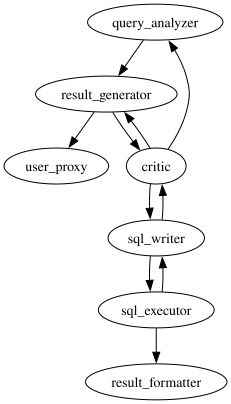

In [12]:
from graphviz import Digraph
from IPython.display import display

# Define the FSM graph
graph_dict = {
    "query_analyzer": ["result_generator"],
    "result_generator": ["user_proxy", "critic"],
    "critic": ["query_analyzer", "sql_writer", "result_generator"],
    "sql_writer": ["sql_executor", "critic"],
    "sql_executor": ["sql_writer", "result_formatter"]
}

# Create a directed graph
dot = Digraph()

# Add nodes and edges
for state, transitions in graph_dict.items():
    dot.node(state)  # Add state
    for next_state in transitions:
        dot.edge(state, next_state)  # Add transition

# Render inline in Jupyter
display(dot)


In [33]:
import json
import csv 
assistant = AssistantAgent(
    name="tables_analyzer",
    system_message="""
        You are an SQL expert of joinable tables.
        You will take two joinable tables from a datalake, each containing five example entries for each column. 
        You are required to GENERATE a natural language question that necessitate joining these two tables. 
        Do not generate the answer.
        Report also the corresponding SQL code block.
        Be sure to use the correct column names in the SQL block, and put column names inside ``.
        Generate the natural language question do not add any other info.
        Make sure that SQL is write in the way that always return at least one result.
        Make sure that table names are inside ''.
    """,
    llm_config=llm_config,
    is_termination_msg=lambda x: x.get("content", "").rstrip().endswith("TERMINATE"),
)

user_proxy = UserProxyAgent(
    name="user_proxy",
    system_message="A human admin. Execute code when needed",
    code_execution_config={
        "last_n_messages": 3,
        "executor": LocalCommandLineCodeExecutor(work_dir="groupchat"),
    },
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").rstrip().endswith("TERMINATE"),
    max_consecutive_auto_reply=5
)


def check_termination(msg: Dict):
    if "tool_responses" not in msg:
        return False
    json_str = msg["tool_responses"][0]["content"]
    obj = json.loads(json_str)
    return "error" not in obj or obj["error"] is None and obj["reward"] == 1


sql_writer = AssistantAgent(
    "sql_executor",
    system_message="You are good at writing SQL queries. Always respond with a function call to execute_sql(). Do not add other argoument not requested",
    is_termination_msg=check_termination,
    llm_config=llm_config,
)


@sql_writer.register_for_llm(description="Function for executing SQL query and returning a response")
@user_proxy.register_for_execution()
def execute_sql(
    question:  Annotated[str, "Think about the corresponding natural language question to SQL."],
    human_like_question: Annotated[str, "Convert question without using technical or specific column names. Instead, replace them with more relatable and descriptive terms to make the question feel intuitive and conversational."],
    reflection: Annotated[str, "Think about what to do"], sql: Annotated[str, "SQL query"], table1: Annotated[str, "name of the first table"], table2: Annotated[str, "name of the second table"]
) -> Annotated[Dict[str, str], "Dictionary with keys 'result' and 'error'"]:
        connection = None
        error = None
        result = None
        
        try:
            # Connect to the SQLite database
            connection = sqlite3.connect('UK_tables.db')
            cursor = connection.cursor()
            
            # Execute the SQL query
            cursor.execute(sql)
            result = cursor.fetchall()
            
            # Commit changes if the query modifies the database
            connection.commit()
            
        except sqlite3.Error as e:
            # Handle SQL errors
            error = str(e)
        
        finally:
            if connection:
                # Close the connection
                connection.close()
        
        if error:
            return {
                "error": error,
                "wrong_result": result if result else "No result",
                "correct_result": "N/A"
            }
        
        
        elif len(result) == 0:
            return {
                "error":  'Empty result',
                "result": "No result",
                "correct_result": "N/A"
            }
            
            
        else:
            # save results to csv
            # Check if the CSV file exists
            file_exists = os.path.isfile('query_results.csv')
 
            with open('query_results.csv', 'a', newline='') as csvfile:
                csv_writer = csv.writer(csvfile)
                if not file_exists:
                    csv_writer.writerow(['question', 'query', 'sql', 'table1', 'table2'])  # Write header
            
                csv_writer.writerow([human_like_question, question, sql, table1, table2])

            return {
                "result": result,
            }

# sql_rewriter = AssistantAgent(
#     "rewriter",
#     system_message="Given an SQL query and an error try to modify the sql to avoid the error. Write only the new sql.",
#     is_termination_msg=check_termination,
#     llm_config=mistral_sql,
# )

#groupchat = GroupChat(agents=[sql_writer, user_proxy, sql_rewriter], messages=[], max_round=30, speaker_selection_method="round_robin")
#manager = GroupChatManager(groupchat=groupchat, llm_config=mistral_sql, system_message="When the task is completed say TERMINATE",)

In [34]:
op_tables

,query_table,candidate_table
0,UK_CSV0000000000001955.csv,UK_CSV0000000000000270.csv
1,UK_CSV0000000000001626.csv,UK_CSV0000000000003912.csv
2,UK_CSV0000000000000759.csv,UK_CSV0000000000011254.csv
3,UK_CSV0000000000002588.csv,UK_CSV0000000000007746.csv
4,UK_CSV0000000000000987.csv,UK_CSV0000000000009096.csv
...,...,...
177,UK_CSV0000000000004295.csv,UK_CSV0000000000010811.csv
178,UK_CSV0000000000004295.csv,UK_CSV0000000000002491.csv
179,UK_CSV0000000000004295.csv,UK_CSV0000000000008979.csv
180,UK_CSV0000000000004295.csv,UK_CSV0000000000005090.csv


In [35]:
table1_name = op_tables[['query_table']].iloc[0].values[0]
table2_name = op_tables[["candidate_table"]].iloc[0].values[0]
table_list = os.listdir(f'../data/clustered_rows/representative_table_rows_{OPENDS_NAME}')

In [36]:
table1_name[:-4]

'UK_CSV0000000000001955'

In [37]:
# import zipfile

# # Open the ZIP file
# with zipfile.ZipFile(DATASET_PATH, "r") as z:
#     # List files inside the ZIP
#     file_list = [
#         f
#         for f in z.namelist()
#         if not f.startswith("__MACOSX")
#         and not f.endswith("/")
#         and not f.split("/")[-1].startswith("._")
#     ]
    
#     print(file_list)

#     # Extract only filenames
#     clean_file_names = [f.split("/")[-1] for f in file_list]

# print("Filtered Files:", clean_file_names)

In [38]:
# import pandas as pd
# import sqlite3
# import numpy as np


# # Function to import a CSV file into SQLite
# def import_csv_to_sqlite(csv_file, table_name, db_connection):
#     with zipfile.ZipFile(DATASET_PATH, 'r') as z:

#         with z.open(f'datasets_UK/{csv_file}') as f:
#             df = pd.read_csv(f)
#             df.to_sql(table_name, db_connection, if_exists='replace', index=False)
#             print(f"Imported {csv_file} into {table_name}")

# # Create a connection to the SQLite database
# conn = sqlite3.connect('uk_tables.db')

# # List of CSV files and corresponding table names
# #csv_files = np.unique(list(filter(file_exists, tables)))
# table_names = list(map(lambda x: x.replace('.csv', ''), clean_file_names))

# # Import each CSV file into the SQLite database
# for csv_file, table_name in zip(clean_file_names, table_names):
#     import_csv_to_sqlite(csv_file, table_name, conn)
# # Close the database connection
# conn.close()

In [39]:
# conn = sqlite3.connect('UK_tables.db')
# cursor = conn.cursor()

# # Execute a query to retrieve all table names
# cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# # Fetch all results from the executed query
# tables = cursor.fetchall()

# # Print the list of tables
# for table in tables:
#     print(table[0])

In [40]:
with open(f'../data/clustered_rows/representative_table_rows_{OPENDS_NAME}/{table1_name[:-4]}.txt', 'r') as file:
        table1 = file.read()
        
with open(f'../data/clustered_rows/representative_table_rows_{OPENDS_NAME}/{table2_name[:-4]}.txt', 'r') as file:
    table2 = file.read()


from sqlalchemy import create_engine, MetaData, Table
from sqlalchemy.schema import CreateTable

engine = create_engine('sqlite:////Users/angelomozzillo/orqa/notebooks/UK_tables.db')
metadata = MetaData()


s1 = str(CreateTable(Table(table1_name[:-4], metadata, autoload_with=engine)).compile(engine))
s2 = str(CreateTable(Table(table2_name[:-4], metadata, autoload_with=engine)).compile(engine))

In [41]:
print(s1)


CREATE TABLE "UK_CSV0000000000001955" (
	"Crime ID" TEXT, 
	"Month" TEXT, 
	"Reported by" TEXT, 
	"Falls within" TEXT, 
	"Longitude" REAL, 
	"Latitude" REAL, 
	"Location" TEXT, 
	"LSOA code" TEXT, 
	"LSOA name" TEXT, 
	"Crime type" TEXT, 
	"Last outcome category" TEXT
)




In [42]:
old = []

In [52]:
message = f"""
These are two joinable tables:
##########################
Table '{table1_name[:-4]}': {s1} 

Example:
{table1}
##########################
Table '{table2_name[:-4]}': {s2} 

Example:
{table2}
##########################

make sure to be a lot different from old question:
{old}
You are required to GENERATE a natural language question that necessitate joining these two tables. 
Do not generate the answer.
Report also the corresponding SQL code block.
Rembember that table 1 is '{table1_name[:-4]}' and table 2 name is '{table2_name[:-4]}'.
Be sure to use the correct column and table names in the SQL block, and put column names inside '' (do not pass table_column as argoument).
Generate the natural language question do not add any other info.
Do not translate columns to english if they are in french, use names as it is.
Make sure that table names are inside ''.
If the tables in your opinion do not do join sai TERMINATE.
WRITE ONLY NATURAL QUESTION:
"""


In [53]:
print(message)


These are two joinable tables:
##########################
Table 'UK_CSV0000000000001955': 
CREATE TABLE "UK_CSV0000000000001955" (
	"Crime ID" TEXT, 
	"Month" TEXT, 
	"Reported by" TEXT, 
	"Falls within" TEXT, 
	"Longitude" REAL, 
	"Latitude" REAL, 
	"Location" TEXT, 
	"LSOA code" TEXT, 
	"LSOA name" TEXT, 
	"Crime type" TEXT, 
	"Last outcome category" TEXT
)

 

Example:
                                                        Crime ID   Month                Reported by               Falls within  Longitude  Latitude                     Location LSOA code               LSOA name                   Crime type       Last outcome category
3685ce4e476e3e3eaf8c27506667741378e760824e0d595ac013c3faf8db4e6c 2022-05 Hertfordshire Constabulary Hertfordshire Constabulary  -0.378245 51.709145  On or near Old Watford Road E01023732          St Albans 020D Violence and sexual offences Unable to prosecute suspect
b970877cd855274e43e3def78d28d9b44741ec57b08e742d32b8db7f1073e77e 2022-05 Hertfordshire C

In [51]:

os.environ["AUTOGEN_USE_DOCKER"] = "False"
user_proxy = UserProxyAgent("user_proxy", human_input_mode="NEVER", max_consecutive_auto_reply=5)

def check_termination(msg: Dict):
    if "tool_responses" not in msg:
        return False
    json_str = msg["tool_responses"][0]["content"]
    obj = json.loads(json_str)
    return "error" not in obj or obj["error"] is None and obj["reward"] == 1

@sql_writer.register_for_llm(description="Function for executing SQL query and returning a response")
@user_proxy.register_for_execution()
def execute_sql(
    question:  Annotated[str, "Think about the corresponding natural language question to SQL."],
    human_like_question: Annotated[str, "Convert question without using technical or specific column names. Instead, replace them with more relatable and descriptive terms to make the question feel intuitive and conversational."],
    reflection: Annotated[str, "Think about what to do"], sql: Annotated[str, "SQL query"], table1: Annotated[str, "name of the first table"], table2: Annotated[str, "name of the second table"]
) -> Annotated[Dict[str, str], "Dictionary with keys 'result' and 'error'"]:
        connection = None
        error = None
        result = None
        
        try:
            # Connect to the SQLite database
            connection = sqlite3.connect('UK_tables.db')
            cursor = connection.cursor()
            
            # Execute the SQL query
            cursor.execute(sql)
            result = cursor.fetchall()
            
            # Commit changes if the query modifies the database
            connection.commit()
            
        except sqlite3.Error as e:
            # Handle SQL errors
            error = str(e)
        
        finally:
            if connection:
                # Close the connection
                connection.close()
        
        if error:
            return {
                "error": error,
                "wrong_result": result if result else "No result",
                "correct_result": "N/A"
            }
        
        
        elif len(result) == 0:
            return {
                "error":  'Empty result',
                "result": "No result",
                "correct_result": "N/A"
            }
            
            
        else:
            # save results to csv
            # Check if the CSV file exists
            file_exists = os.path.isfile('query_results.csv')
 
            with open('query_results.csv', 'a', newline='') as csvfile:
                csv_writer = csv.writer(csvfile)
                if not file_exists:
                    csv_writer.writerow(['question', 'query', 'sql', 'table1', 'table2'])  # Write header
            
                csv_writer.writerow([human_like_question, question, sql, table1, table2])

            return {
                "result": result,
            }

user_proxy.initiate_chat(sql_writer, message=message)

user_proxy (to sql_executor):


These are two joinable tables:
##########################
Table 'UK_CSV0000000000001955': 
CREATE TABLE "UK_CSV0000000000001955" (
	"Crime ID" TEXT, 
	"Month" TEXT, 
	"Reported by" TEXT, 
	"Falls within" TEXT, 
	"Longitude" REAL, 
	"Latitude" REAL, 
	"Location" TEXT, 
	"LSOA code" TEXT, 
	"LSOA name" TEXT, 
	"Crime type" TEXT, 
	"Last outcome category" TEXT
)

 

Example:
                                                        Crime ID   Month                Reported by               Falls within  Longitude  Latitude                     Location LSOA code               LSOA name                   Crime type       Last outcome category
3685ce4e476e3e3eaf8c27506667741378e760824e0d595ac013c3faf8db4e6c 2022-05 Hertfordshire Constabulary Hertfordshire Constabulary  -0.378245 51.709145  On or near Old Watford Road E01023732          St Albans 020D Violence and sexual offences Unable to prosecute suspect
b970877cd855274e43e3def78d28d9b44741ec57b08e742d32b8db7f1

KeyboardInterrupt: 